In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def read_MoM_results(individual_sizes, path, file_name, num_snp):
    """
    read_MoM_results from cluster output files.

    parameters:
    individual_sizes: list of individual sizes (e.g., [1000, 2000, 4000])
    path: directory path where the result files are stored
    num_snp: number of SNPs used in the analysis
    file_name: base name of the result files (e.g., "MoM_results")

    returns:
    A dictionary with individual sizes as keys and corresponding DataFrames as values.
    """ 

    data_dict = {}
    for n in individual_sizes:
        full_file_name = f"{file_name}_n{n}m{num_snp}.txt"  # different variable
        file_path = os.path.join(path, full_file_name)
        
        df = pd.read_csv(file_path, header=None)
        df[0] = df[0].astype(str).str.replace('(', '', regex=False).astype(float)
        df[1] = df[1].astype(str).str.replace(')', '', regex=False).astype(float)
        
        data_dict[n] = df
        
    return data_dict

def read_MoM_results_add(individual_sizes, path, file_name, num_snp):
    """
    read_MoM_results from cluster output files with three columns (a, gxg, e).
    parameters:
    individual_sizes: list of individual sizes (e.g., [1000, 2000, 4000])
    path: directory path where the result files are stored
    num_snp: number of SNPs used in the analysis
    file_name: base name of the result files (e.g., "MoM_results")
    returns:
    A dictionary with individual sizes as keys and corresponding DataFrames as values.
    Each DataFrame has three columns: [0]=a (additive), [1]=gxg (epistatic), [2]=e (error).
    """
    data_dict = {}
    for n in individual_sizes:
        full_file_name = f"{file_name}_n{n}m{num_snp}.txt"
        file_path = os.path.join(path, full_file_name)

        df = pd.read_csv(file_path, header=None)
        df[0] = df[0].astype(str).str.replace('(', '', regex=False).astype(float)
        df[1] = df[1].astype(str).astype(float)
        df[2] = df[2].astype(str).str.replace(')', '', regex=False).astype(float)

        data_dict[n] = df

    return data_dict
    
def plot_relative_error_across_groups_combined(*data_dicts, x_labels, individual_sizes, col_num, real_value, ymin, ymax, x_axis_name="Group", title=None, save_name=None):
    """
    Plot relative errors with box plots in journal style.
    
    Parameters:
    -----------
    col_num : int
        Column index to plot. 
        0 = additive (a), 1 = epistatic (gxg), 2 = error (e)
        For two-column data: 0 = gxg, 1 = e
    save_name : str
        Filename without extension (e.g., 'my_plot'). 
        PDF will be saved to the same directory as the script.
        If None, plot is only displayed.
    """
    
    # Set high-quality rendering
    plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 10,
        'axes.linewidth': 1,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.major.width': 1,
        'ytick.major.width': 1,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'figure.dpi': 150,
        'savefig.dpi': 600,
    })
    
    # Gather data for all combinations
    data_list = []
    combined_labels = []
    bottom_labels = []
    
    for label, data_dict in zip(x_labels, data_dicts):
        for n in individual_sizes:
            df = data_dict[n]
            col_values = df.iloc[:, col_num].values - real_value
            combined_labels.append(f"{label}\nn={n:,}")
            bottom_labels.append(f"n = {n:,}")
            data_list.append(pd.DataFrame({"value": col_values, "group": combined_labels[-1]}))
    
    data = pd.concat(data_list, ignore_index=True)
    data["group"] = pd.Categorical(data["group"], categories=combined_labels, ordered=True)
    
    # Compute summary statistics
    summary = (
        data.groupby("group", observed=True)["value"]
        .agg(["mean", "std", "count"])
        .loc[combined_labels]
    )
    
    # Perform one-sample t-test for each group (mean != 0)
    p_values = {}
    for combined_label in combined_labels:
        group_data = data[data["group"] == combined_label]["value"].values
        t_stat, p_val = stats.ttest_1samp(group_data, 0)
        p_values[combined_label] = p_val
    
    summary["p_value"] = summary.index.map(p_values)
    
    # x-axis positions
    x_positions = np.arange(len(summary))
    
    # Create figure
    fig, ax = plt.subplots(figsize=(3 + len(combined_labels) * 0.8, 5))
    
    # Extend y-axis for labels above plot
    ymax_extended = ymax + 0.25 * (ymax - ymin)
    ax.set_ylim(ymin, ymax_extended)
    ax.set_xlim(-0.6, len(combined_labels) - 0.4)
    
    # Add alternating white/gray background for EACH BOX
    for i in range(len(combined_labels)):
        x_start = i - 0.5
        x_end = i + 0.5
        if i % 2 == 0:
            ax.axvspan(x_start, x_end, facecolor='white', alpha=1.0, zorder=0)
        else:
            ax.axvspan(x_start, x_end, facecolor='#E8E8E8', alpha=0.8, zorder=0)
    
    # Prepare data for box plots
    box_data = [data[data["group"] == label]["value"].values for label in combined_labels]
    
    # Define colors
    box_color = '#3274A1'
    median_color = '#CC0000'
    label_color = '#000000'
    
    # Create box plots - NO OUTLIERS
    bp = ax.boxplot(
        box_data,
        positions=x_positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(linewidth=1.5, edgecolor=box_color, facecolor='white'),
        whiskerprops=dict(linewidth=1.2, color=box_color),
        capprops=dict(linewidth=1.2, color=box_color),
        medianprops=dict(linewidth=2, color=median_color)
    )
    
    # Add m = label at top
    for i, label in enumerate(x_labels):
        group_center = (i + 0.5) * len(individual_sizes) - 0.5
        ax.text(
            group_center, ymax_extended - 0.01 * (ymax_extended - ymin),
            label,
            ha='center', va='top', fontsize=11, fontweight='bold', color=label_color
        )
    
    # Significance stars, Mean, and SD labels
    for i, (combined_label, row) in enumerate(summary.iterrows()):
        p_val = row['p_value']
        if p_val < 0.001:
            sig_stars = '***'
        elif p_val < 0.01:
            sig_stars = '**'
        elif p_val < 0.05:
            sig_stars = '*'
        else:
            sig_stars = 'ns'
        
        ax.text(
            i, ymax_extended - 0.08 * (ymax_extended - ymin),
            sig_stars,
            ha='center', va='top', fontsize=11, fontweight='bold',
            color=label_color
        )
        
        ax.text(
            i, ymax_extended - 0.15 * (ymax_extended - ymin),
            f"Mean={row['mean']:.3f}",
            ha='center', va='top', fontsize=9, fontweight='bold',
            color=label_color
        )
        
        ax.text(
            i, ymax_extended - 0.22 * (ymax_extended - ymin),
            f"SD={row['std']:.3f}",
            ha='center', va='top', fontsize=9, fontweight='bold',
            color=label_color
        )
    
    # Determine y-axis label based on col_num
    # Auto-detect based on number of columns in the first DataFrame
    first_df = list(data_dicts[0].values())[0]
    num_cols = first_df.shape[1]
    
    if num_cols == 3:
        # Three-column case: [a, gxg, e]
        if col_num == 0:
            theta_simple = r"$\sigma^2_{a}$"
        elif col_num == 1:
            theta_simple = r"$\sigma^2_{g \times g}$"
        elif col_num == 2:
            theta_simple = r"$\sigma^2_{e}$"
        else:
            theta_simple = "Parameter"
    else:
        # Two-column case: [gxg, e]
        if col_num == 0:
            theta_simple = r"$\sigma^2_{g \times g}$"
        elif col_num == 1:
            theta_simple = r"$\sigma^2_{e}$"
        else:
            theta_simple = "Parameter"
    
    # Reference line at zero
    ax.axhline(0, color='#666666', linestyle='--', linewidth=0.8, zorder=1)
    
    # Axis labels
    ax.set_xlabel("Sample size (n)", fontsize=10, labelpad=8)
    ax.set_ylabel(f"Relative error ({theta_simple})", fontsize=10, labelpad=8)
    
    # Y-axis ticks
    yticks = np.arange(np.ceil(ymin * 4) / 4, ymax + 0.01, 0.25)
    yticks = [y for y in yticks if y <= ymax]
    ax.set_yticks(yticks)
    
    # X-tick labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(bottom_labels, fontsize=9)
    
    # Title
    if title:
        ax.set_title(title, fontsize=11, pad=10, fontweight='normal')
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    
    ax.tick_params(axis='both', which='major', labelsize=9, colors='#333333')
    
    plt.tight_layout()
    
    # Save PDF to script directory
    if save_name:
        script_dir = os.getcwd()
        save_path = os.path.join(script_dir, f"{save_name}.pdf")
        
        plt.savefig(
            save_path,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none',
            format='pdf',
            transparent=False,
            pad_inches=0.1
        )
        print(f"PDF saved to: {save_path}")
    
    plt.show()
    
    # Reset rcParams
    plt.rcParams.update(plt.rcParamsDefault)

def plot_relative_error_combined_vertical(data_dicts_list, x_labels_list, individual_sizes, col_num, real_value, ymin, ymax, save_name=None):
    """
    Plot multiple relative error box plots as vertical subplots in one figure.
    
    Parameters:
    -----------
    data_dicts_list : list of data_dicts
        e.g., [Contiguous_raw_1k, Contiguous_raw_2k, Contiguous_raw_4k]
    x_labels_list : list of x_labels
        e.g., [["m = 1000"], ["m = 2000"], ["m = 4000"]]
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import os
    from scipy import stats
    
    # Set high-quality rendering
    plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 10,
        'axes.linewidth': 1,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.major.width': 1,
        'ytick.major.width': 1,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'figure.dpi': 150,
        'savefig.dpi': 600,
    })
    
    num_plots = len(data_dicts_list)
    # Flattened figure: wider and shorter per subplot
    fig, axes = plt.subplots(num_plots, 1, figsize=(10, 3 * num_plots), sharex=True)
    
    if num_plots == 1:
        axes = [axes]
    
    for ax_idx, (data_dict, x_labels) in enumerate(zip(data_dicts_list, x_labels_list)):
        ax = axes[ax_idx]
        
        # Gather data for all combinations
        data_list = []
        combined_labels = []
        bottom_labels = []
        
        for label in x_labels:
            for n in individual_sizes:
                df = data_dict[n]
                col_values = df.iloc[:, col_num].values - real_value
                combined_labels.append(f"{label}\nn={n:,}")
                bottom_labels.append(f"n = {n:,}")
                data_list.append(pd.DataFrame({"value": col_values, "group": combined_labels[-1]}))
        
        data = pd.concat(data_list, ignore_index=True)
        data["group"] = pd.Categorical(data["group"], categories=combined_labels, ordered=True)
        
        # Compute summary statistics
        summary = (
            data.groupby("group", observed=True)["value"]
            .agg(["mean", "std", "count"])
            .loc[combined_labels]
        )
        
        # Perform one-sample t-test for each group (mean != 0)
        p_values = {}
        for combined_label in combined_labels:
            group_data = data[data["group"] == combined_label]["value"].values
            t_stat, p_val = stats.ttest_1samp(group_data, 0)
            p_values[combined_label] = p_val
        
        summary["p_value"] = summary.index.map(p_values)
        
        # x-axis positions
        x_positions = np.arange(len(summary))
        
        # Extend y-axis for labels above plot
        ymax_extended = ymax + 0.25 * (ymax - ymin)
        ax.set_ylim(ymin, ymax_extended)
        ax.set_xlim(-0.6, len(combined_labels) - 0.4)
        
        # Add alternating white/gray background for EACH BOX
        for i in range(len(combined_labels)):
            x_start = i - 0.5
            x_end = i + 0.5
            if i % 2 == 0:
                ax.axvspan(x_start, x_end, facecolor='white', alpha=1.0, zorder=0)
            else:
                ax.axvspan(x_start, x_end, facecolor='#E8E8E8', alpha=0.8, zorder=0)
        
        # Prepare data for box plots
        box_data = [data[data["group"] == label]["value"].values for label in combined_labels]
        
        # Define colors
        box_color = '#3274A1'
        median_color = '#CC0000'
        label_color = '#000000'
        
        # Create box plots - NO OUTLIERS
        bp = ax.boxplot(
            box_data,
            positions=x_positions,
            widths=0.5,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(linewidth=1.5, edgecolor=box_color, facecolor='white'),
            whiskerprops=dict(linewidth=1.2, color=box_color),
            capprops=dict(linewidth=1.2, color=box_color),
            medianprops=dict(linewidth=2, color=median_color)
        )
        
        # Add m = label at top (as title)
        for i, label in enumerate(x_labels):
            group_center = (i + 0.5) * len(individual_sizes) - 0.5
            ax.text(
                group_center, ymax_extended - 0.01 * (ymax_extended - ymin),
                label,
                ha='center', va='top', fontsize=11, fontweight='bold', color=label_color
            )
        
        # Significance stars, Mean, and SD labels
        for i, (combined_label, row) in enumerate(summary.iterrows()):
            p_val = row['p_value']
            if p_val < 0.001:
                sig_stars = '***'
            elif p_val < 0.01:
                sig_stars = '**'
            elif p_val < 0.05:
                sig_stars = '*'
            else:
                sig_stars = 'ns'
            
            ax.text(
                i, ymax_extended - 0.08 * (ymax_extended - ymin),
                sig_stars,
                ha='center', va='top', fontsize=10, fontweight='bold',
                color=label_color
            )
            
            ax.text(
                i, ymax_extended - 0.15 * (ymax_extended - ymin),
                f"Mean={row['mean']:.3f}",
                ha='center', va='top', fontsize=8, fontweight='bold',
                color=label_color
            )
            
            ax.text(
                i, ymax_extended - 0.22 * (ymax_extended - ymin),
                f"SD={row['std']:.3f}",
                ha='center', va='top', fontsize=8, fontweight='bold',
                color=label_color
            )
        
        # Theta label for y-axis
        if col_num == 0:
            theta_simple = r"$\sigma^2_{g \times g}$"
        elif col_num == 1:
            theta_simple = r"$\sigma^2_{e}$"
        else:
            theta_simple = "Parameter"
        
        # Reference line at zero
        ax.axhline(0, color='#666666', linestyle='--', linewidth=0.8, zorder=1)
        
        # Y-axis label
        ax.set_ylabel(f"Relative error ({theta_simple})", fontsize=10, labelpad=8)
        
        # Y-axis ticks
        yticks = np.arange(np.ceil(ymin * 4) / 4, ymax + 0.01, 0.25)
        yticks = [y for y in yticks if y <= ymax]
        ax.set_yticks(yticks)
        
        # X-tick labels (only for bottom plot)
        ax.set_xticks(x_positions)
        if ax_idx == num_plots - 1:
            ax.set_xticklabels(bottom_labels, fontsize=9)
            ax.set_xlabel("Sample size (n)", fontsize=10, labelpad=8)
        else:
            ax.set_xticklabels([])
        
        # Panel label (A), (B), (C)
        panel_label = chr(65 + ax_idx)  # A, B, C, ...
        ax.text(-0.08, 1.02, f"({panel_label})", transform=ax.transAxes, 
                fontsize=12, fontweight='bold', va='bottom', ha='left')
        
        # Clean up spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#333333')
        ax.spines['bottom'].set_color('#333333')
        
        ax.tick_params(axis='both', which='major', labelsize=9, colors='#333333')
    
    plt.tight_layout()
    
    # Save PDF to script directory
    if save_name:
        script_dir = os.getcwd()
        save_path = os.path.join(script_dir, f"{save_name}.pdf")
        
        plt.savefig(
            save_path,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none',
            format='pdf',
            transparent=False,
            pad_inches=0.1
        )
        print(f"PDF saved to: {save_path}")
    
    plt.show()
    
    # Reset rcParams
    plt.rcParams.update(plt.rcParamsDefault)


def plot_three_effects_single_m(data_dict, individual_sizes, real_values, m_label, ymin, ymax, save_name=None):
    """
    Plot relative errors for three variance components (a, gxg, e) in stacked panels.
    Compact version with reduced vertical spacing.
    """
    from scipy import stats
    
    plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 9,
        'axes.linewidth': 1,
        'figure.dpi': 150,
        'savefig.dpi': 600,
    })
    
    components = [
        (0, r"$\sigma^2_{a}$"),
        (1, r"$\sigma^2_{g \times g}$"),
        (2, r"$\sigma^2_{e}$"),
    ]
    
    num_boxes = len(individual_sizes)
    
    # Compact figure: each panel is shorter
    fig, axes = plt.subplots(
        3, 1,
        figsize=(3 + num_boxes * 0.7, 7.5),  # Reduced from 12 to 7.5
        sharex=True,
        gridspec_kw={'hspace': 0.25}  # Tighter spacing between panels
    )
    
    box_color = '#3274A1'
    median_color = '#CC0000'
    label_color = '#000000'
    
    ymax_extended = ymax + 0.30 * (ymax - ymin)  # Slightly more room for labels
    
    for ax_idx, (col_num, theta_label) in enumerate(components):
        ax = axes[ax_idx]
        real_value = real_values[col_num]
        
        box_data = []
        means = []
        sds = []
        p_values = []
        bottom_labels = []
        
        for n in individual_sizes:
            df = data_dict[n]
            col_values = df.iloc[:, col_num].values - real_value
            box_data.append(col_values)
            means.append(np.mean(col_values))
            sds.append(np.std(col_values, ddof=1))
            _, p_val = stats.ttest_1samp(col_values, 0)
            p_values.append(p_val)
            bottom_labels.append(f"n = {n:,}")
        
        x_positions = np.arange(len(individual_sizes))
        
        ax.set_ylim(ymin, ymax_extended)
        ax.set_xlim(-0.6, len(individual_sizes) - 0.4)
        
        # Alternating background
        for i in range(len(individual_sizes)):
            color = 'white' if i % 2 == 0 else '#E8E8E8'
            ax.axvspan(i - 0.5, i + 0.5, facecolor=color, alpha=1.0 if i % 2 == 0 else 0.8, zorder=0)
        
        # Box plots
        ax.boxplot(
            box_data,
            positions=x_positions,
            widths=0.5,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(linewidth=1.2, edgecolor=box_color, facecolor='white'),
            whiskerprops=dict(linewidth=1, color=box_color),
            capprops=dict(linewidth=1, color=box_color),
            medianprops=dict(linewidth=1.5, color=median_color)
        )
        
        # m = label at top of top panel only
        if ax_idx == 0:
            ax.text(
                (len(individual_sizes) - 1) / 2,
                ymax_extended - 0.01 * (ymax_extended - ymin),
                m_label,
                ha='center', va='top', fontsize=10, fontweight='bold', color=label_color
            )
        
        # Offset for labels
        top_offset = 0.09 if ax_idx == 0 else 0.03
        
        for i, (mean_val, sd_val, p_val) in enumerate(zip(means, sds, p_values)):
            if p_val < 0.001:
                sig_stars = '***'
            elif p_val < 0.01:
                sig_stars = '**'
            elif p_val < 0.05:
                sig_stars = '*'
            else:
                sig_stars = 'ns'
            
            ax.text(
                i, ymax_extended - top_offset * (ymax_extended - ymin),
                sig_stars,
                ha='center', va='top', fontsize=9, fontweight='bold', color=label_color
            )
            ax.text(
                i, ymax_extended - (top_offset + 0.08) * (ymax_extended - ymin),
                f"Mean={mean_val:.3f}",
                ha='center', va='top', fontsize=7.5, fontweight='bold', color=label_color
            )
            ax.text(
                i, ymax_extended - (top_offset + 0.16) * (ymax_extended - ymin),
                f"SD={sd_val:.3f}",
                ha='center', va='top', fontsize=7.5, fontweight='bold', color=label_color
            )
        
        # Reference line at zero
        ax.axhline(0, color='#666666', linestyle='--', linewidth=0.8, zorder=1)
        
        # Y-axis label
        ax.set_ylabel(f"Relative error ({theta_label})", fontsize=9, labelpad=6)
        
        # Y-axis ticks: fewer ticks for compactness
        yticks = np.arange(np.ceil(ymin * 2) / 2, ymax + 0.01, 0.5)
        yticks = [y for y in yticks if y <= ymax]
        ax.set_yticks(yticks)
        
        # X-axis (only bottom)
        ax.set_xticks(x_positions)
        if ax_idx == len(components) - 1:
            ax.set_xticklabels(bottom_labels, fontsize=8)
            ax.set_xlabel("Sample size (n)", fontsize=9, labelpad=6)
        else:
            ax.set_xticklabels([])
        
        # Spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#333333')
        ax.spines['bottom'].set_color('#333333')
        ax.tick_params(axis='both', which='major', labelsize=8, colors='#333333')
    

    
    if save_name:
        script_dir = os.getcwd()
        save_path = os.path.join(script_dir, f"{save_name}.pdf")
        plt.savefig(save_path, bbox_inches='tight', facecolor='white',
                    edgecolor='none', format='pdf', transparent=False, pad_inches=0.1)
        print(f"PDF saved to: {save_path}")
    
    plt.show()
    plt.rcParams.update(plt.rcParamsDefault)

def plot_gxg_across_densities_xaxis(data_dicts, density_labels, individual_sizes, real_value, m_label, ymin, ymax, save_name=None):
    """
    Plot relative errors of gxg estimates with density on x-axis.
    Each panel = one sample size; within each panel, boxplots = different densities.
    
    Parameters:
    -----------
    data_dicts : list of dict
        List of dictionaries, one per density. Each dict maps n -> DataFrame with col 1 = gxg.
    density_labels : list of str
        Labels for each density (e.g., ["1.0", "0.5", "0.1", "0.02"])
    individual_sizes : list of int
        Sample sizes (e.g., [1000, 2000, 4000, 8000, 16000, 32000]).
    real_value : float
        True sigma^2_gxg value.
    m_label : str
        Label for SNP count shown at top (e.g., "m = 1000").
    ymin, ymax : float
        Y-axis limits for each panel.
    save_name : str, optional
        Filename without extension.
    """
    from scipy import stats
    
    plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 9,
        'axes.linewidth': 1,
        'figure.dpi': 150,
        'savefig.dpi': 600,
    })
    
    n_panels = len(individual_sizes)  # One panel per sample size
    num_boxes = len(data_dicts)  # Number of density values per panel
    
    # Create stacked panels (one per sample size)
    fig, axes = plt.subplots(
        n_panels, 1,
        figsize=(3 + num_boxes * 0.7, 2.5 * n_panels),
        sharex=True
    )
    
    if n_panels == 1:
        axes = [axes]
    
    box_color = '#3274A1'
    median_color = '#CC0000'
    label_color = '#000000'
    
    ymax_extended = ymax + 0.30 * (ymax - ymin)
    
    for ax_idx, n in enumerate(individual_sizes):
        ax = axes[ax_idx]
        
        # Gather data for this sample size across densities
        box_data = []
        means = []
        sds = []
        p_values = []
        bottom_labels = []
        
        for data_dict, density_label in zip(data_dicts, density_labels):
            df = data_dict[n]
            col_values = df.iloc[:, 1].values - real_value  # column 1 is gxg
            box_data.append(col_values)
            means.append(np.mean(col_values))
            sds.append(np.std(col_values, ddof=1))
            _, p_val = stats.ttest_1samp(col_values, 0)
            p_values.append(p_val)
            bottom_labels.append(f"density = {density_label}")
        
        x_positions = np.arange(num_boxes)
        
        ax.set_ylim(ymin, ymax_extended)
        ax.set_xlim(-0.6, num_boxes - 0.4)
        
        # Alternating background
        for i in range(num_boxes):
            color = 'white' if i % 2 == 0 else '#E8E8E8'
            ax.axvspan(i - 0.5, i + 0.5, facecolor=color, alpha=1.0 if i % 2 == 0 else 0.8, zorder=0)
        
        # Box plots
        ax.boxplot(
            box_data,
            positions=x_positions,
            widths=0.5,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(linewidth=1.2, edgecolor=box_color, facecolor='white'),
            whiskerprops=dict(linewidth=1, color=box_color),
            capprops=dict(linewidth=1, color=box_color),
            medianprops=dict(linewidth=1.5, color=median_color)
        )
        
        # m = label at top of top panel only
        if ax_idx == 0:
            ax.text(
                (num_boxes - 1) / 2,
                ymax_extended - 0.01 * (ymax_extended - ymin),
                m_label,
                ha='center', va='top', fontsize=10, fontweight='bold', color=label_color
            )
        
        # Significance, Mean, SD labels at top
        top_offset = 0.09 if ax_idx == 0 else 0.03
        for i, (mean_val, sd_val, p_val) in enumerate(zip(means, sds, p_values)):
            if p_val < 0.001:
                sig_stars = '***'
            elif p_val < 0.01:
                sig_stars = '**'
            elif p_val < 0.05:
                sig_stars = '*'
            else:
                sig_stars = 'ns'
            
            ax.text(i, ymax_extended - top_offset * (ymax_extended - ymin),
                    sig_stars, ha='center', va='top', fontsize=9,
                    fontweight='bold', color=label_color)
            ax.text(i, ymax_extended - (top_offset + 0.07) * (ymax_extended - ymin),
                    f"Mean={mean_val:.3f}", ha='center', va='top',
                    fontsize=7.5, fontweight='bold', color=label_color)
            ax.text(i, ymax_extended - (top_offset + 0.14) * (ymax_extended - ymin),
                    f"SD={sd_val:.3f}", ha='center', va='top',
                    fontsize=7.5, fontweight='bold', color=label_color)
        
        # Reference line at zero
        ax.axhline(0, color='#666666', linestyle='--', linewidth=0.8, zorder=1)
        
        # Y-axis label uses sample size
        ax.set_ylabel(f"Relative error ($\\sigma^2_{{g \\times g}}$, n = {n:,})", 
                     fontsize=9, labelpad=6)
        
        # Y-axis ticks
        yticks = np.arange(np.ceil(ymin * 2) / 2, ymax + 0.01, 0.5)
        yticks = [y for y in yticks if y <= ymax]
        ax.set_yticks(yticks)
        
        # X-axis (only bottom)
        ax.set_xticks(x_positions)
        if ax_idx == n_panels - 1:
            ax.set_xticklabels(bottom_labels, fontsize=9)
            ax.set_xlabel("Density", fontsize=10, labelpad=6)
        else:
            ax.set_xticklabels([])
        
        # Spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#333333')
        ax.spines['bottom'].set_color('#333333')
        ax.tick_params(axis='both', which='major', labelsize=8, colors='#333333')
    
    plt.subplots_adjust(left=0.12, right=0.97, top=0.96, bottom=0.08, hspace=0.25)
    
    if save_name:
        script_dir = os.getcwd()
        save_path = os.path.join(script_dir, f"{save_name}.pdf")
        plt.savefig(save_path, bbox_inches='tight', facecolor='white',
                    edgecolor='none', format='pdf', transparent=False, pad_inches=0.1)
        print(f"PDF saved to: {save_path}")
    
    plt.show()
    plt.rcParams.update(plt.rcParamsDefault)

In [26]:
### read data
individual_sizes = [1000,2000,4000,8000,16000,32000]
Random1k = read_MoM_results(individual_sizes,"OnlyW_data/","infinitesimal_Random_STD",1000)
s2gxg005 = read_MoM_results(individual_sizes,"OnlyW_data/","Random_s2gxg0.05_s2e0.95",1000)
Random2k = read_MoM_results(individual_sizes,"OnlyW_data/","infinitesimal_Random_STD",2000)

Special02gxg = read_MoM_results_add(individual_sizes,"Sparse_data/","Special0.2gxg",1000)
SNPdensity1 = read_MoM_results_add(individual_sizes,"Sparse_data/","Random_s2a0.2_s2gxg0.7_s2e0.1_SNPdensity1.0",1000)
SNPdensity05 = read_MoM_results_add(individual_sizes,"Sparse_data/","Random_s2a0.2_s2gxg0.7_s2e0.1_SNPdensity0.5",1000)
SNPdensity01 = read_MoM_results_add(individual_sizes,"Sparse_data/","Random_s2a0.2_s2gxg0.7_s2e0.1_SNPdensity0.1",1000)
SNPdensity002 = read_MoM_results_add(individual_sizes,"Sparse_data/","Random_s2a0.2_s2gxg0.7_s2e0.1_SNPdensity0.02",1000)
pairdensity002 = read_MoM_results_add(individual_sizes,"Sparse_data/","Random_s2a0.2_s2gxg0.7_s2e0.1_pairdensity0.02",1000)

individual_sizes = [1000,2000,4000,8000]
check = read_MoM_results_add(individual_sizes,"Sparse_data/","Random_s2a0.2_s2gxg0.7_s2e0.1_pairdensity1.0",1000)


Random SNP s2a0.2 s2gxg0.7 s2e0.1
Only causal SNP has causal interaction
Sparse density0.5
PDF saved to: G:\Full-gene-level-GxG-Estimation\Thesis\Sparse_model_three_components.pdf


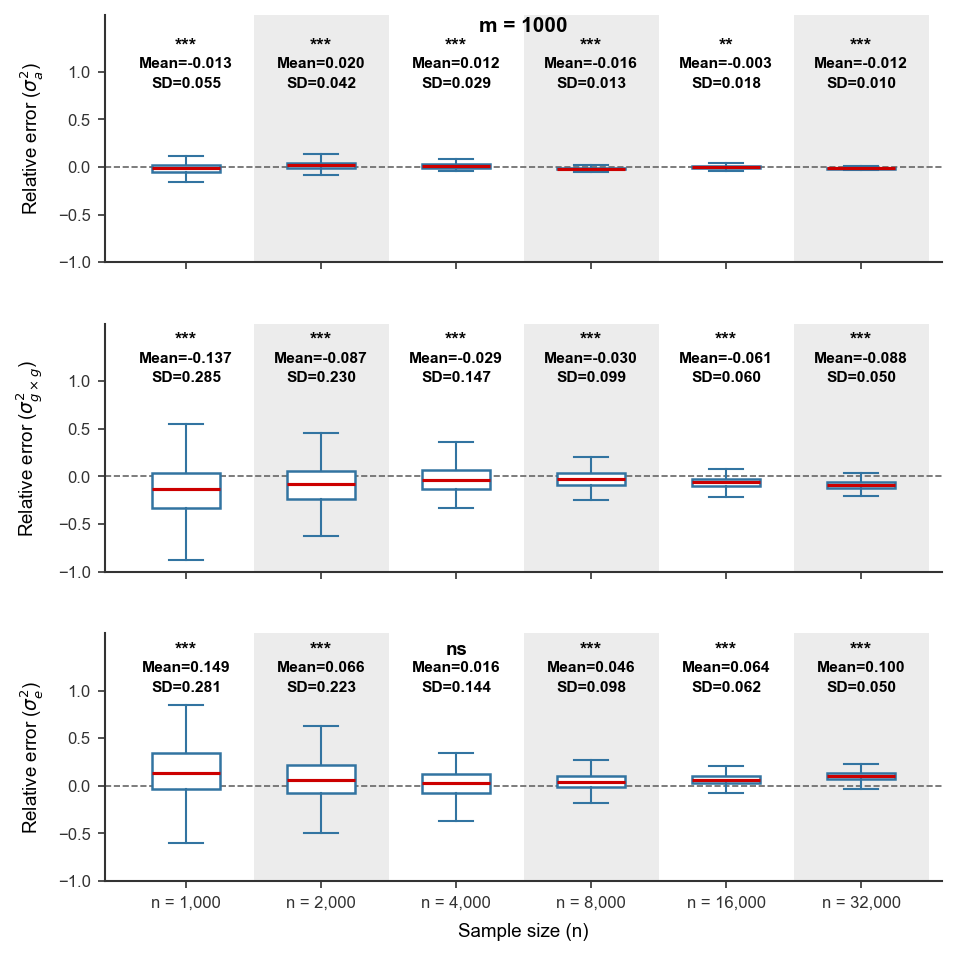

In [25]:
print("Random SNP s2a0.2 s2gxg0.7 s2e0.1\nOnly causal SNP has causal interaction\nSparse density0.5")
plot_three_effects_single_m(
    data_dict=Special02gxg,
    individual_sizes = [1000,2000,4000,8000,16000,32000],
    real_values=[0.2, 0.7, 0.1], 
    m_label="m = 1000",
    ymin=-1, ymax=1,
    save_name="Sparse_model_three_components"
)

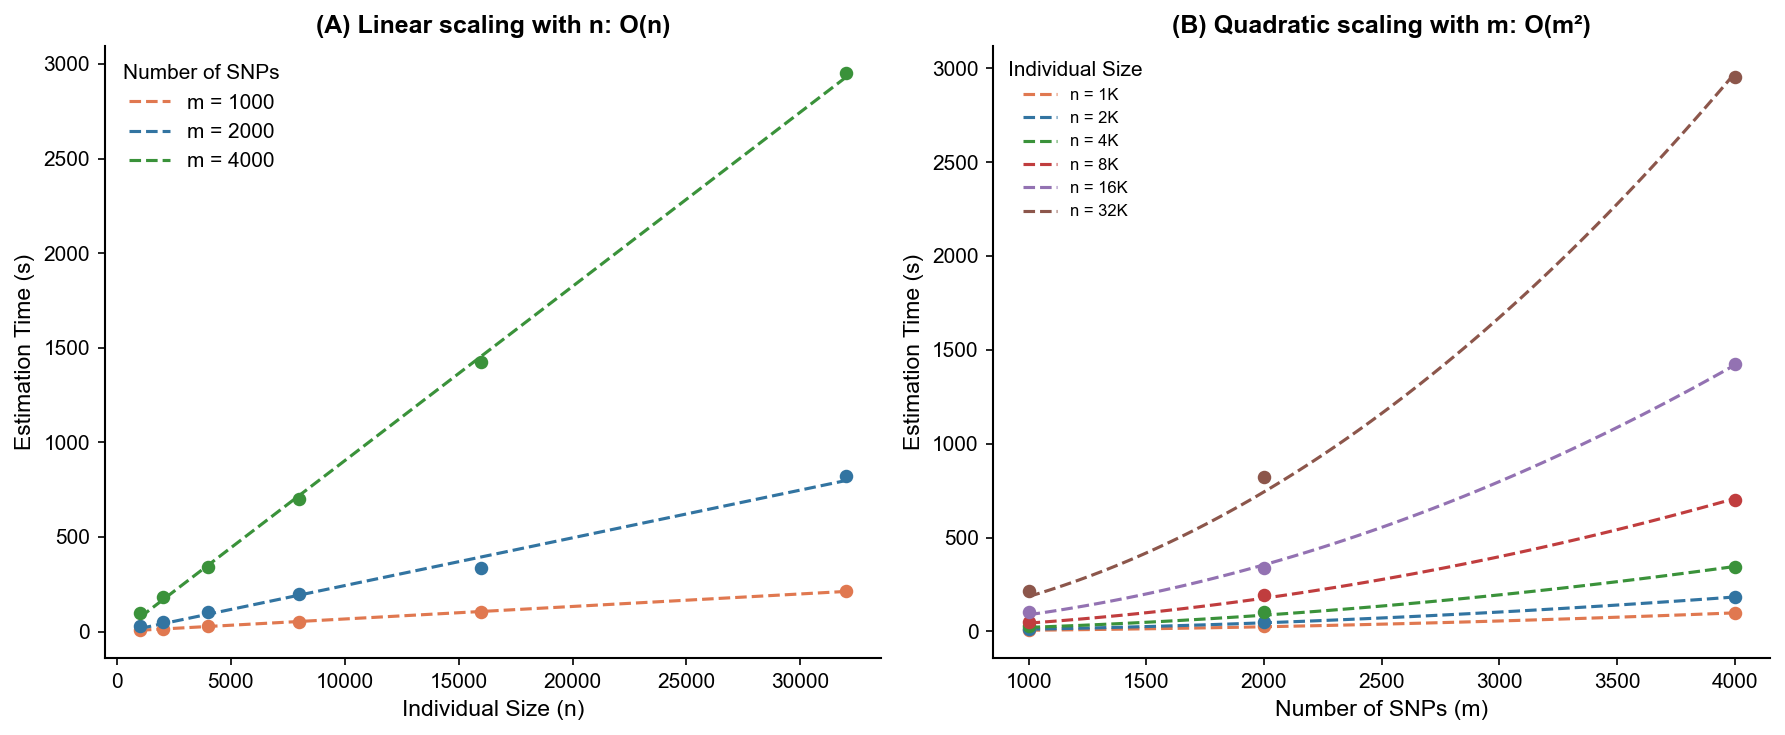

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define sample sizes and SNP counts
n_sizes = [1000, 2000, 4000, 8000, 16000, 32000]
m_sizes = [1000, 2000, 4000]

# Read all files and compute means
time_data = {}

for m in m_sizes:
    for n in n_sizes:
        df = pd.read_csv(f"data/time/n{n}m{m}time.txt", header=None)
        time_data[(n, m)] = df[0].mean()

# Set style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 10,
    'axes.linewidth': 1,
    'figure.dpi': 150,
})

# Define fitting functions
def linear(x, a, b):
    return a * x + b

def quadratic_simple(x, a):
    return a * x**2

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


colors_m = ['#E07850', '#3274A1', '#3A923A']

for i, m in enumerate(m_sizes):
    means = [time_data[(n, m)] for n in n_sizes]
    n_array = np.array(n_sizes)
    
    ax1.scatter(n_array, means, marker='o', s=30, color=colors_m[i], zorder=3)
    
    popt, _ = curve_fit(linear, n_array, means)
    n_fit = np.linspace(min(n_sizes), max(n_sizes), 100)
    ax1.plot(n_fit, linear(n_fit, *popt), '--', color=colors_m[i], linewidth=1.5,
             label=f'm = {m}')

ax1.set_xlabel('Individual Size (n)', fontsize=11)
ax1.set_ylabel('Estimation Time (s)', fontsize=11)
ax1.legend(title='Number of SNPs', frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title('(A) Linear scaling with n: O(n)', fontsize=12, fontweight='bold', loc='center')

colors_n = ['#E07850', '#3274A1', '#3A923A', '#C03D3E', '#9372B2', '#8C564B']

for i, n in enumerate(n_sizes):
    means = [time_data[(n, m)] for m in m_sizes]
    m_array = np.array(m_sizes)
    
    ax2.scatter(m_array, means, marker='o', s=30, color=colors_n[i], zorder=3)
    
    popt, _ = curve_fit(quadratic_simple, m_array, means)
    m_fit = np.linspace(min(m_sizes), max(m_sizes), 100)
    ax2.plot(m_fit, quadratic_simple(m_fit, *popt), '--', color=colors_n[i], linewidth=1.5,
             label=f'n = {n//1000}K')

ax2.set_xlabel('Number of SNPs (m)', fontsize=11)
ax2.set_ylabel('Estimation Time (s)', fontsize=11)
ax2.legend(title='Individual Size', frameon=False, loc='upper left', fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('(B) Quadratic scaling with m: O(m²)', fontsize=12, fontweight='bold', loc='center')

plt.tight_layout()
plt.savefig('time_scaling.pdf', bbox_inches='tight', format='pdf')
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

In [207]:
import pandas as pd
import numpy as np
from scipy import stats

# Read the CSV
SE_Random_raw_n1000m1000 = pd.read_csv("data/SE/SE_Random_raw_n4000m1000.txt", header=None)

# Clean the first column - remove the opening parenthesis
SE_Random_raw_n1000m1000[0] = SE_Random_raw_n1000m1000[0].str.replace('(', '').astype(float)
ASE = np.sqrt(SE_Random_raw_n1000m1000[0])

# Calculate mean and SD
col1_mean = ASE.mean()
col1_sd = ASE.std()
n = len(ASE)

# Calculate 95% CI
se = col1_sd / np.sqrt(n)  # Standard error of the mean
ci_95 = 1.96 * se

# Or using t-distribution (more accurate for smaller samples)
ci_95_t = stats.t.ppf(0.975, df=n-1) * se

print(f"Mean: {col1_mean:.4f}")
print(f"SD: {col1_sd:.4f}")
print(f"n: {n}")
print(f"95% CI (z): {col1_mean:.4f} ± {ci_95:.4f}")
print(f"95% CI (t): {col1_mean:.4f} ± {ci_95_t:.4f}")
print(f"95% CI: [{col1_mean - ci_95:.4f}, {col1_mean + ci_95:.4f}]")

Mean: 0.1124
SD: 0.0045
n: 300
95% CI (z): 0.1124 ± 0.0005
95% CI (t): 0.1124 ± 0.0005
95% CI: [0.1119, 0.1129]


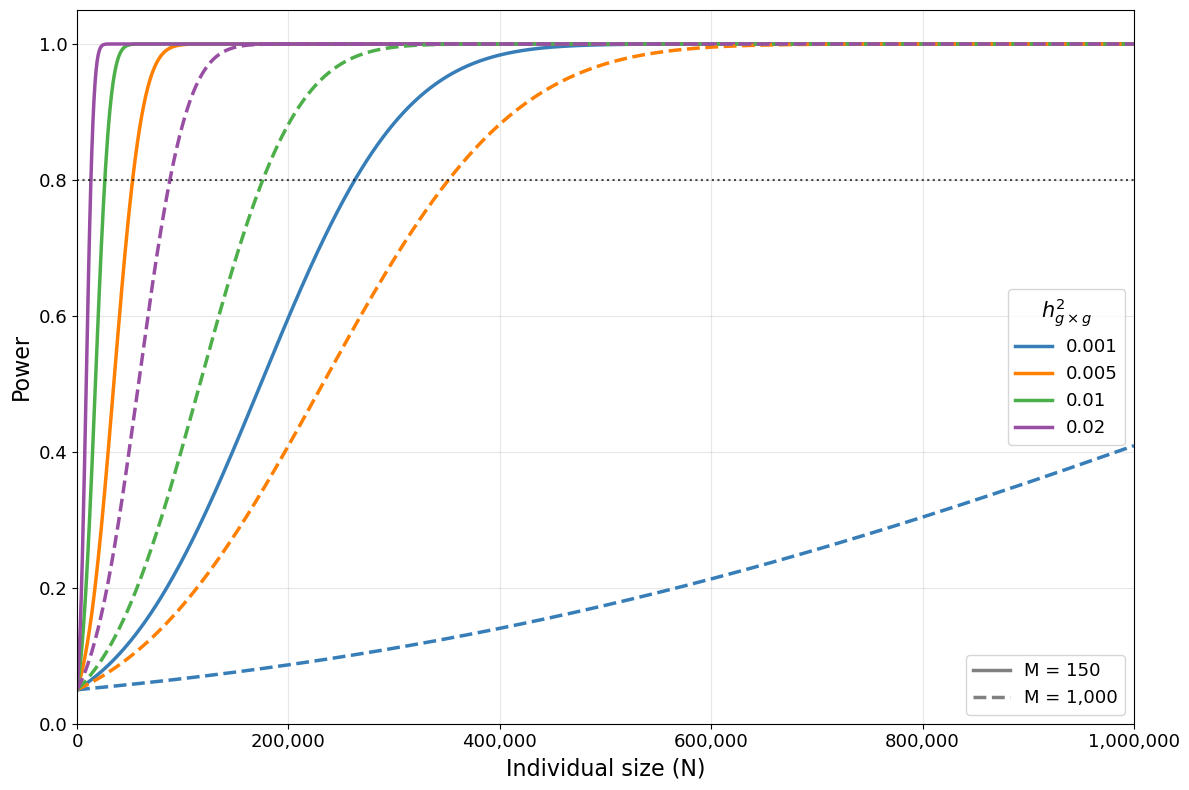

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.lines import Line2D


def power_one_sided(N, sigma2_gxg, M, alpha=0.05):
    """One-sided Wald power (matching Hivert 2021)."""
    SE = np.sqrt(M**2 - M) / (np.sqrt(2) * N)
    z_alpha = norm.ppf(1 - alpha)
    return norm.cdf(sigma2_gxg / SE - z_alpha)


def plot_power_curves(M_values=[100, 1000], 
                      effect_sizes=[0.01, 0.05, 0.1, 0.2],
                      N_max=50_000,
                      N_target=250_000,
                      alpha=0.05,
                      save_path='power_curves.pdf'):
    """Plot power curves using one-sided Wald test."""
    # Use more sample points and start from N=1 for smoother curves near zero
    N_range = np.linspace(1, N_max, 1000)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # set color
    colors = ['#377eb8', '#ff7f00', '#4daf4a', '#984ea3']
    
    # Solid lines (smaller M)
    for sigma2, color in zip(effect_sizes, colors):
        powers = [power_one_sided(N, sigma2, M_values[0], alpha) for N in N_range]
        ax.plot(N_range, powers, color=color, linestyle='-', linewidth=2.5)
    
    # Dashed lines (larger M)
    for sigma2, color in zip(effect_sizes, colors):
        powers = [power_one_sided(N, sigma2, M_values[1], alpha) for N in N_range]
        ax.plot(N_range, powers, color=color, linestyle='--', linewidth=2.5)
    
    ax.axhline(y=0.80, color='black', linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Axis labels and limits
    ax.set_xlabel('Individual size (N)', fontsize=16)
    ax.set_ylabel('Power', fontsize=16)
    ax.set_xlim(0, N_max)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    
    # Effect size legend
    effect_legend = [Line2D([0], [0], color=c, linewidth=2.5, label=f'{s}') 
                     for s, c in zip(effect_sizes, colors)]
    leg1 = ax.legend(handles=effect_legend, 
                     title=r'$h^2_{g \times g}$',
                     loc='center right', 
                     fontsize=13, 
                     title_fontsize=15,
                     frameon=True)
    ax.add_artist(leg1)
    
    # M legend
    M_legend = [
        Line2D([0], [0], color='gray', linewidth=2.5, linestyle='-', 
               label=f'M = {M_values[0]:,}'),
        Line2D([0], [0], color='gray', linewidth=2.5, linestyle='--', 
               label=f'M = {M_values[1]:,}'),
    ]
    ax.legend(handles=M_legend, loc='lower right', fontsize=13)
    
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()  # FIXED: Removed markdown link artifact


if __name__ == '__main__':
    plot_power_curves(
        M_values=[150, 1000],
        effect_sizes=[0.001, 0.005, 0.01, 0.02],
        N_max=1_000_000,
        save_path='power_curves_thesis.pdf'
    )